# From Pilot to Payoff - 02: Q1 - Global EDA and Adoption Patterns

Part of the IS630 group project. The combined notebook was split into 7 self-contained modules for readability. Run the setup block below first.

| # | Notebook | Content |
|---|---|---|
| 01 | Setup & Data Prep | Problem/objectives (S2), data sources & preparation (S3) |
| 02 | Q1 Global EDA | Section 4.1 |
| 03 | Q2 Country Readiness | Section 4.2 |
| 04 | Q3 Firm-Level Drivers | Section 4.3 |
| 05 | Q4 Business Payoff | Section 4.4 |
| 06 | Q5 Workforce & Bayesian | Section 4.5 |
| 07 | Conclusion & Summary | Section 5 |


## Setup and data preparation

*Re-runs the shared imports, data loading, feature engineering, and standardisation so the notebook is self-contained. Identical across the analysis modules; see `01_setup_and_data_prep.ipynb` for the documented version with the data dictionary.*

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols, logit
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

# Folder for saving generated figures.
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
industry_summary = pd.read_csv('ai_industry_summary.csv')

print('Dataset shapes')
print(f'company adoption: {company.shape[0]:,} rows x {company.shape[1]:,} columns')
print(f'country index:    {country_index.shape[0]:,} rows x {country_index.shape[1]:,} columns')
print(f'industry summary: {industry_summary.shape[0]:,} rows x {industry_summary.shape[1]:,} columns')

company.head(3)


Dataset shapes
company adoption: 150,000 rows x 43 columns
country index:    30 rows x 8 columns
industry summary: 9 rows x 8 columns


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering and merge.
quarter_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
company = company.copy()
company['quarter_num'] = company['quarter'].map(quarter_map)
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)
company['net_jobs_created'] = company['jobs_created'] - company['jobs_displaced']
company['net_jobs_per_100_employees'] = company['net_jobs_created'] / company['num_employees'] * 100
company['reskilling_rate_per_100_employees'] = company['reskilled_employees'] / company['num_employees'] * 100

# Log transform for the skewed investment variable. log1p handles zero values safely.
company['log_ai_investment_per_employee'] = np.log1p(company['ai_investment_per_employee'])

country_model = country_index.drop(columns=['region'])
country_model['log_gdp_per_capita'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_ai_patent_filings_2024'] = np.log1p(country_model['ai_patent_filings_2024'])

df = company.merge(country_model, on='country', how='left')

# Latest observation per company for robustness checks.
latest_obs = (df.sort_values(['company_id', 'survey_year', 'quarter_num'])
                .groupby('company_id', as_index=False)
                .tail(1)
                .reset_index(drop=True))

# Digital maturity tertiles for interaction models.
df['digital_maturity_tertile'] = pd.qcut(
    df['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)
latest_obs['digital_maturity_tertile'] = pd.qcut(
    latest_obs['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)

merge_check = df[['country', 'digital_maturity_index']].isna().mean().rename('missing_rate')
print(f'Merged modelling data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Latest-company robustness data: {latest_obs.shape[0]:,} rows')
print('\nCountry-index missing check:')
print(merge_check)


Merged modelling data: 150,000 rows x 58 columns
Latest-company robustness data: 10,000 rows

Country-index missing check:
country                   0.0
digital_maturity_index    0.0
Name: missing_rate, dtype: float64


In [4]:
# Standardise numeric predictors used in regression models.
standardise_cols = [
    'ai_training_hours', 'num_ai_tools_used', 'ai_projects_active', 'years_using_ai',
    'ai_budget_percentage', 'log_ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score'
]

for col in standardise_cols:
    mean = df[col].mean()
    std = df[col].std(ddof=0)
    df[f'z_{col}'] = (df[col] - mean) / std
    latest_obs[f'z_{col}'] = (latest_obs[col] - mean) / std

print('Created z-score variables for regression comparability.')


Created z-score variables for regression comparability.


In [5]:
stage_order = ['none', 'pilot', 'partial', 'full']

## Section 4: Methodology and Results

### 4.1 Q1 - Global EDA and Adoption Patterns

This section follows the Session 1 and Session 2 workflow: summary statistics, grouped summaries, and visualisation. 


Overall AI adoption-stage distribution
                   count  share_percent
ai_adoption_stage                      
none                5198           3.47
pilot              64317          42.88
partial            78800          52.53
full                1685           1.12

Full adoption is rare: only 1.12% of observations are "full",
so "advanced" (partial OR full) is largely a partial-vs-pilot contrast.

Advanced adoption rate by year (rises over time):
survey_year
2023    45.4
2024    51.2
2025    56.4
2026    61.6


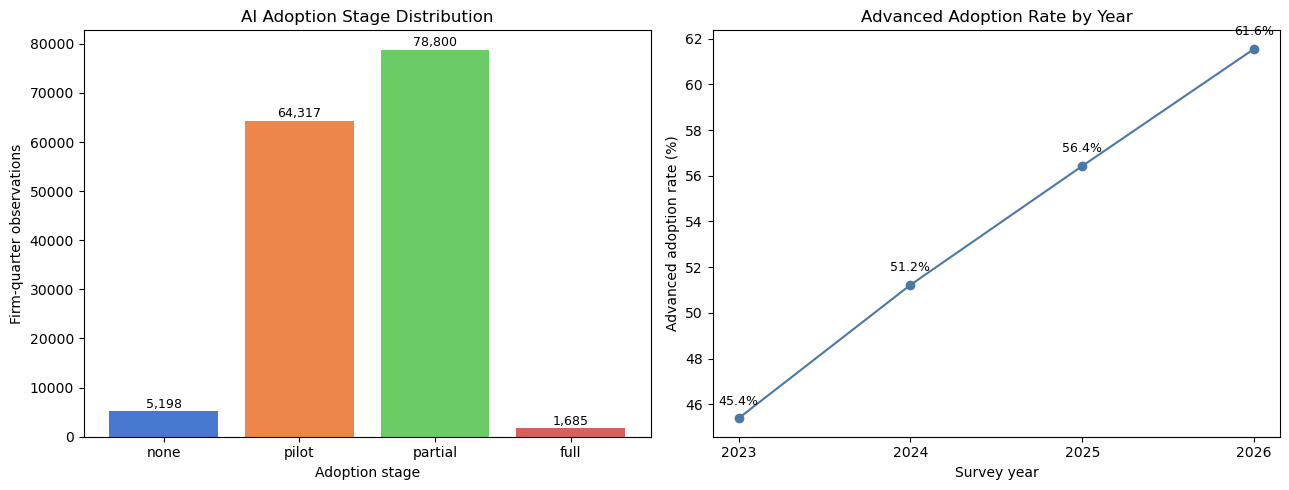

In [6]:
stage_order = ['none', 'pilot', 'partial', 'full']
stage_counts = df['ai_adoption_stage'].value_counts().reindex(stage_order)
stage_share = (stage_counts / stage_counts.sum()).rename('share')

# Advanced adoption rises over time, so the pooled rate understates the most recent state.
yearly_adv = df.groupby('survey_year')['advanced_adoption'].mean() * 100

print('Overall AI adoption-stage distribution')
print(pd.DataFrame({'count': stage_counts, 'share_percent': (stage_share * 100).round(2)}))
print(f'\nFull adoption is rare: only {stage_share["full"]:.2%} of observations are "full",')
print('so "advanced" (partial OR full) is largely a partial-vs-pilot contrast.')

print('\nAdvanced adoption rate by year (rises over time):')
print(yearly_adv.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(stage_counts.index, stage_counts.values, color=sns.color_palette('muted', 4))
axes[0].set_title('AI Adoption Stage Distribution')
axes[0].set_xlabel('Adoption stage')
axes[0].set_ylabel('Firm-quarter observations')
for i, value in enumerate(stage_counts.values):
    axes[0].text(i, value + 700, f'{value:,}', ha='center', fontsize=9)

axes[1].plot(yearly_adv.index, yearly_adv.values, marker='o', color='#4c78a8')
axes[1].set_title('Advanced Adoption Rate by Year')
axes[1].set_xlabel('Survey year')
axes[1].set_ylabel('Advanced adoption rate (%)')
axes[1].set_xticks(yearly_adv.index)
for x, y in zip(yearly_adv.index, yearly_adv.values):
    axes[1].text(x, y + 0.6, f'{y:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_01_adoption_distribution_trend.png', bbox_inches='tight')
plt.show()



Advanced adoption by Region
               advanced_adoption_rate_percent      n
region                                              
Oceania                                 61.34  10002
North America                           61.00   9740
Europe                                  54.79  40835
South America                           53.10  19909
Asia                                    52.71  49727
Africa                                  46.77  19787

Advanced adoption by Industry
               advanced_adoption_rate_percent      n
industry                                            
Technology                              69.73  21107
Finance                                 59.20  20166
Education                               50.50  15172
Agriculture                             50.47  15570
Logistics                               50.30  12961
Retail                                  49.21  16377
Manufacturing                           49.07  17501
Consulting                             

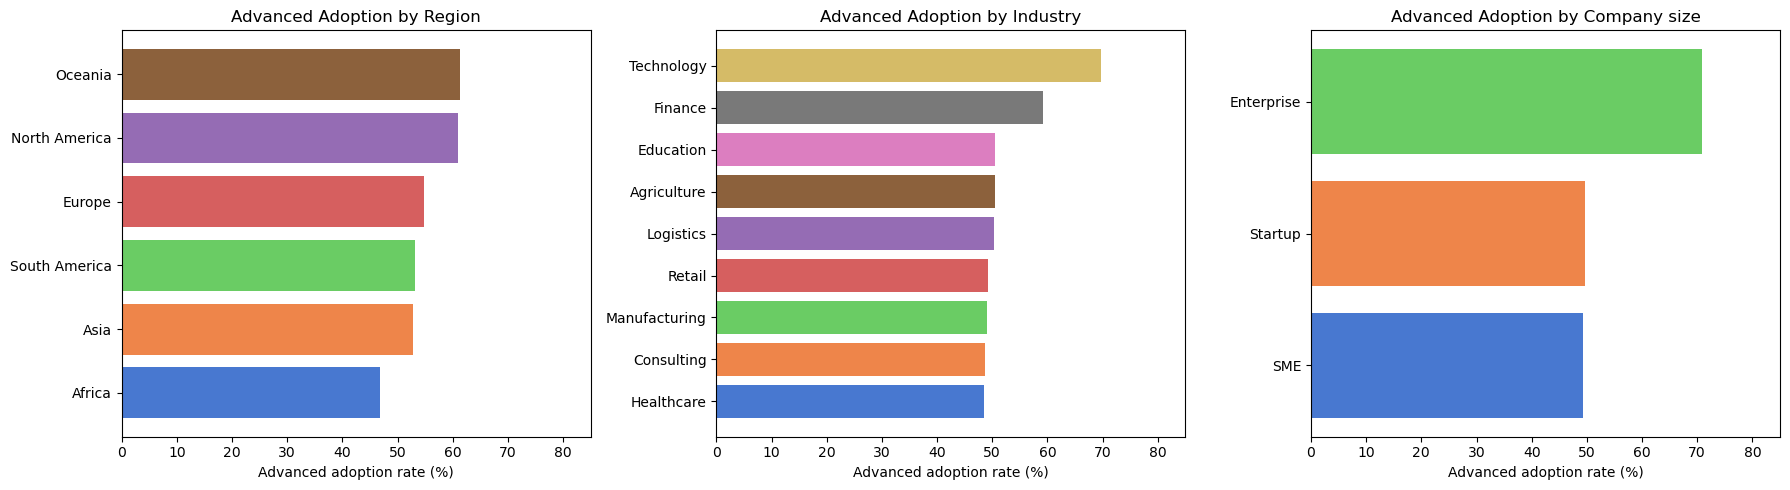

In [7]:
# Adoption rate by key segments.
segment_specs = {
    'region': 'Region',
    'industry': 'Industry',
    'company_size': 'Company size'
}

segment_tables = {}
for col, label in segment_specs.items():
    table = (df.groupby(col)['advanced_adoption']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'advanced_adoption_rate', 'count': 'n'})
               .sort_values('advanced_adoption_rate', ascending=False))
    table['advanced_adoption_rate_percent'] = table['advanced_adoption_rate'] * 100
    segment_tables[col] = table
    print(f'\nAdvanced adoption by {label}')
    print(table[['advanced_adoption_rate_percent', 'n']].round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, label) in zip(axes, segment_specs.items()):
    plot_data = segment_tables[col].sort_values('advanced_adoption_rate_percent')
    ax.barh(plot_data.index, plot_data['advanced_adoption_rate_percent'], color=sns.color_palette('muted', len(plot_data)))
    ax.set_title(f'Advanced Adoption by {label}')
    ax.set_xlabel('Advanced adoption rate (%)')
    ax.set_xlim(0, max(85, plot_data['advanced_adoption_rate_percent'].max() + 5))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_02_adoption_by_segments.png', bbox_inches='tight')
plt.show()


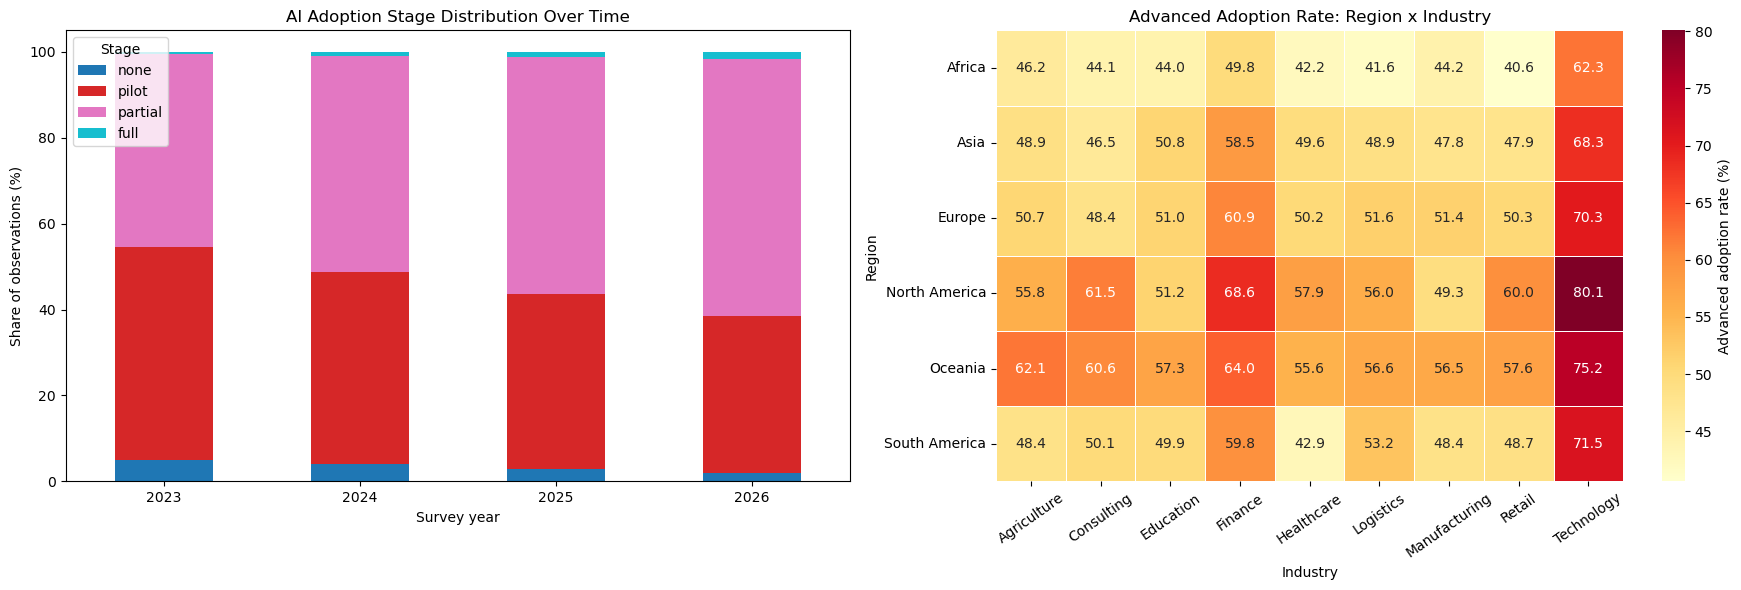

In [8]:
# Time trend and region-industry heatmap.
time_trend = (df.groupby(['survey_year', 'ai_adoption_stage'])
                .size()
                .reset_index(name='count'))
time_pct = time_trend.pivot(index='survey_year', columns='ai_adoption_stage', values='count').fillna(0)
time_pct = time_pct[stage_order].div(time_pct[stage_order].sum(axis=1), axis=0) * 100

pivot_region_industry = df.pivot_table(index='region', columns='industry', values='advanced_adoption', aggfunc='mean') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
time_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10')
axes[0].set_title('AI Adoption Stage Distribution Over Time')
axes[0].set_xlabel('Survey year')
axes[0].set_ylabel('Share of observations (%)')
axes[0].legend(title='Stage', loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

sns.heatmap(pivot_region_industry, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': 'Advanced adoption rate (%)'}, ax=axes[1])
axes[1].set_title('Advanced Adoption Rate: Region x Industry')
axes[1].set_xlabel('Industry')
axes[1].set_ylabel('Region')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_03_time_heatmap.png', bbox_inches='tight')
plt.show()
